In [3]:

import os,sys

import pickle#5 as pickle
#import pickle5
import matplotlib.pyplot as plt
from matplotlib import gridspec
import numpy as np
from bin.outputs import output_utilities
import core.GeneralFunctions as GrlFct
import building_geometry.BuildingObject as BuildingObject
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import pandas as pd


In [5]:
os.getcwd()
sys.path


['/Applications/PyCharm.app/Contents/plugins/python-ce/helpers/jupyter_debug',
 '/Applications/PyCharm.app/Contents/plugins/python-ce/helpers/pydev',
 '/Library/Frameworks/Python.framework/Versions/3.9/lib/python39.zip',
 '/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9',
 '/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/lib-dynload',
 '',
 '/Users/alizad/PycharmProjects/NewWorking-MUBES/venv/lib/python3.9/site-packages']

In [ ]:
pickleResult = []
J2KWh = 3600000
allfacade = 0
allwindow = 0
allheatedarea = 0
WWR = {'0': 0.15, '1939': 0.15, '1960': 0.15, '1970': 0.2, '1976': 0.25, '1985': 0.25, '2000': 0.25} #Todo delete here
# for i in range(1):
with open(f'../../examples/NUS/Sim_Results/Building_{1}v0.pickle', 'rb') as f:
    results = pickle.load(f)
print('Hi')
    # wwr = results['BuildDB'].wwr
    # cnst_wwr = sorted([item for item in WWR if float(item) <= results['BuildDB'].year], reverse=True)[0]
    # wwr = WWR[cnst_wwr]
    # Perimeter = results['BuildDB'].perimeter
    # Height = results['BuildDB'].BlocHeight[0]
    # FacadeArea = Perimeter * Height - wwr * Perimeter * Height
    # allfacade+=FacadeArea
    # WindowArea = wwr * Perimeter * Height
    # allwindow += WindowArea
    # allheatedarea+= results['BuildDB'].EPHeatedArea
    #
    # uuid= results['BuildDB'].BuildID['50A_UUID']
    # pickleResult.append({'UUID': results['BuildDB'].BuildID['50A_UUID'],
    #  'Construction year': results['BuildDB'].year,
    #  'HeatedArea':results['BuildDB'].EPHeatedArea,
    #  'Height': Height,
    #  'FacadeArea' : FacadeArea,
    #  'WindowArea': WindowArea,
    #  'Numbers':{'Window': np.sum(results['HeatedArea']['Data_Zone Windows Total Heat Loss Energy'])/(WindowArea*J2KWh),
    #  'Wall': np.sum(results['HeatedArea']['Data_Surface Outside Face Conduction Heat Transfer Energy On Vertical Walls'])/(FacadeArea*J2KWh),
    #  'vent': np.sum(results['HeatedArea']['Data_Zone Ideal Loads Outdoor Air Total Heating Energy'])/(results['BuildDB'].EPHeatedArea*J2KWh)}})

    # Window = np.sum(results['HeatedArea']['Data_Zone Windows Total Heat Loss Energy'])
    # Wall = np.sum(results['HeatedArea']['Data_Surface Outside Face Conduction Heat Transfer Energy On Vertical Walls'])
    # vent = np.sum(results['HeatedArea']['Data_Zone Ideal Loads Outdoor Air Total Heating Energy'])
# print('The loss through window is: ',Window)
# print('The loss through wall is: ',Wall)
# print('The ventilation is: ',vent)

Hi


In [29]:
478/results['BuildDB'].BlocFootprintArea[0]

0.6650666952188574

In [35]:
sum(results['Other']['Data_Electric Load Center Produced Electricity Energy'])/3600000

72428.64462030797

In [38]:
pickleResult

[{'UUID': 'e6654562-2823-4b79-aad4-76e245fedcf5',
  'Construction year': 2006,
  'HeatedArea': 9018.966009012547,
  'Height': 24,
  'FacadeArea': 3114.0616806238936,
  'WindowArea': 1038.0205602079645,
  'Numbers': {'Window': 99.13881503974405,
   'Wall': 16.883114173706566,
   'vent': 7.508386273276611}},
 {'UUID': 'cbf18066-8de7-44ba-8f0f-48ad4d5fbc64',
  'Construction year': 2008,
  'HeatedArea': 11048.160100747607,
  'Height': 18,
  'FacadeArea': 3405.7331609801595,
  'WindowArea': 1135.2443869933866,
  'Numbers': {'Window': 96.49483056153504,
   'Wall': 12.61041528436647,
   'vent': 23.80301373269779}},
 {'UUID': '27d76485-21f0-4d5d-88ca-65400342dc43',
  'Construction year': 1984,
  'HeatedArea': 6004.867999516771,
  'Height': 18,
  'FacadeArea': 2589.8315021846383,
  'WindowArea': 863.2771673948794,
  'Numbers': {'Window': 156.3318398199108,
   'Wall': 26.57554581428702,
   'vent': 29.319289132803043}},
 {'UUID': '581aa9b3-c565-4913-b93d-30c8878d30ca',
  'Construction year': 1936

In [11]:
for idx, j in enumerate(pickleResult):
    print(j['UUID'],f'Building wall {idx}: ', j['Numbers']['Wall'])



e6654562-2823-4b79-aad4-76e245fedcf5 Building wall 0:  14.499365594617158
cbf18066-8de7-44ba-8f0f-48ad4d5fbc64 Building wall 1:  10.82355604672836
27d76485-21f0-4d5d-88ca-65400342dc43 Building wall 2:  18.34164382511103
581aa9b3-c565-4913-b93d-30c8878d30ca Building wall 3:  33.182343591768095
8820ffa6-f2de-4de2-b357-eb25212e4095 Building wall 4:  30.420222194490986
c9a3033b-098f-4ba8-802e-df5afadb98fd Building wall 5:  29.751425664263515
50db9429-4899-42e1-a526-5b27a1f00ad3 Building wall 6:  28.10858527752229
db12582b-f232-404d-b1a6-da49a442b6de Building wall 7:  17.805929233596785
20acaae4-6d05-4c94-8ca4-ecc8bf6b0cd3 Building wall 8:  28.323629457645943
908f7ea6-6d73-4eff-b683-a5d8f671173d Building wall 9:  14.620861979729828


In [31]:
for idx, j in enumerate(pickleResult):
    print(f'Building Window {idx}: ',j['Numbers']['Window'])



Building Window 0:  36.913221770661714
Building Window 1:  36.05620850969223
Building Window 2:  42.4033382855009
Building Window 3:  43.63273569975211
Building Window 4:  43.168223081651135
Building Window 5:  43.06704941430463
Building Window 6:  43.4118703814454
Building Window 7:  43.58121680112659
Building Window 8:  43.7136686259271
Building Window 9:  43.77385017449365


In [27]:
for idx, j in enumerate(pickleResult):
    print(f'Building vent {idx}: ',j['Numbers']['vent'])



Building vent 0:  7.508386273276611
Building vent 1:  23.80301373269779
Building vent 2:  29.319289132803043
Building vent 3:  37.22538069850665
Building vent 4:  38.403109483840694
Building vent 5:  36.76432310150024
Building vent 6:  38.310550224894676
Building vent 7:  37.629724262635754
Building vent 8:  37.5312904740126
Building vent 9:  37.14664866117827


In [36]:
window=0
wall = 0
vent = 0
for i in range(10):
    with open(f'../../examples/Ex4-ParametricStudy/Sim_Results/Building_{i}v0.pickle', 'rb') as f:
        results = pickle.load(f)
    window += np.sum(results['HeatedArea']['Data_Zone Windows Total Heat Loss Energy'])/J2KWh
    wall += np.sum(results['HeatedArea']['Data_Surface Outside Face Conduction Heat Transfer Energy On Vertical Walls'])/J2KWh
    vent += np.sum(results['HeatedArea']['Data_Zone Ideal Loads Outdoor Air Total Heating Energy'])/J2KWh
# print('The loss through window is: ',window)

In [23]:
wall/allfacade #2

20.540401204158595

In [27]:
wall/allfacade #1

30.826136024072444

In [29]:
vent/allheatedarea #1

36.74949178392383

In [37]:
vent/allheatedarea #2


26.52942167557904

In [30]:
window/allwindow #1

143.6899555429171

In [34]:
window/allwindow #2


39.93360525170125

In [3]:
import building_geometry.MUBES_pygeoj as MUBES_pygeoj
os.getcwd()

'/Users/alizad/PycharmProjects/NewWorking-MUBES/bin/outputs'

In [16]:
Buildingsfile = MUBES_pygeoj.load('/Users/alizad/PycharmProjects/NewWorking-MUBES/bin/Generated_Buildings.geojson')

In [17]:
Buildingsfile

In [15]:
import json
from shapely.geometry import shape

with open('/Users/alizad/PycharmProjects/NewWorking-MUBES/bin/Generated_Buildings.geojson', "r", encoding="utf-8") as f:
    data = json.load(f)

for i, feat in enumerate(data["features"]):
    try:
        geom = shape(feat["geometry"])
    except Exception as e:
        print(f"Feature {i}: geometry could not be parsed:", e)

        continue  # go to next feature

    # If geometry is empty or has weird bounds
    if geom.is_empty:
        print(f"Feature {i}: EMPTY geometry")
        continue

    xmin, ymin, xmax, ymax = geom.bounds

    # This is where your error comes from
    if None in (xmin, ymin, xmax, ymax):
        print(f"Feature {i}: bounds are None ->", geom)
        continue   # <-- skip this feature

    # If we reach here, it’s safe to use the bounds
    width  = xmax - xmin
    height = ymax - ymin
    print(f"Feature {i}: width={width}, height={height}")


Feature 0: width=12.465000554453582, height=9.023995437659323
Feature 1: width=16.035999126848765, height=21.193002781830728
Feature 2: width=13.387996566249058, height=11.201993690803647
Feature 3: width=19.812000357196666, height=17.306997562758625
Feature 4: width=18.670995550462976, height=18.975001245737076
Feature 5: width=13.892002795822918, height=16.868996303528547
Feature 6: width=13.54800203756895, height=16.60599610861391
Feature 7: width=14.97199559956789, height=20.481003045104444
Feature 8: width=62.70800018985756, height=39.336996112018824
Feature 9: width=6.500996793154627, height=8.698001170530915
Feature 10: width=12.200997083215043, height=12.3680021148175
Feature 11: width=25.514000271447003, height=28.55000365432352
Feature 12: width=11.794998119119555, height=11.836999343708158
Feature 13: width=17.36900113313459, height=14.03299877885729
Feature 14: width=9.290000835550018, height=37.56899677962065
Feature 15: width=20.400000116904266, height=31.038006900809705


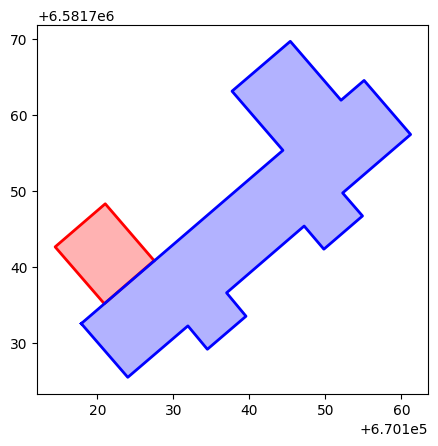

In [1]:
from shapely.geometry import Polygon
import matplotlib.pyplot as plt

# Your footprints
fp1 = [(670127.45333, 6581740.85744),
       (670121.028,   6581748.32794),
       (670114.433,   6581742.65794),
       (670120.90483, 6581735.17907)]

fp2 = [(670117.874,  6581732.56893),
       (670123.992,  6581725.49994),
       (670131.903,  6581732.26594),
       (670134.461,  6581729.18893),
       (670139.546,  6581733.53594),
       (670136.988,  6581736.61294),
       (670147.195,  6581745.40094),
       (670149.788,  6581742.35594),
       (670154.873,  6581746.72593),
       (670152.256,  6581749.75094),
       (670161.203,  6581757.44494),
       (670155.08,   6581764.55694),
       (670152.047,  6581761.94994),
       (670145.373,  6581769.70293),
       (670137.705,  6581763.14294),
       (670144.406,  6581755.36193)]

poly1 = Polygon(fp1)
poly2 = Polygon(fp2)

for poly, color in [(poly1, "red"), (poly2, "blue")]:
    x, y = poly.exterior.xy
    plt.plot(x, y, color=color, linewidth=2)
    plt.fill(x, y, color=color, alpha=0.3)

plt.gca().set_aspect("equal", adjustable="box")
plt.show()


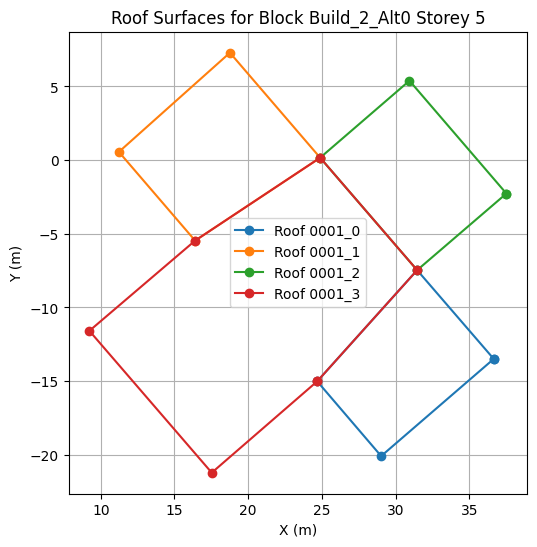

In [1]:
import matplotlib.pyplot as plt

# Define the polygons from the user's BUILDINGSURFACE:DETAILED data
poly_0 = [(36.6662, -13.49),
          (31.4682, -7.467),
          (24.6872, -15.01),
          (29.0272, -20.083)]

poly_1 = [(24.8872, 0.162),
          (18.7644, 7.2864),
          (11.2306, 0.5566),
          (16.4032, -5.464)]

poly_2 = [(37.5242, -2.268),
          (30.9462, 5.387),
          (24.8872, 0.162),
          (31.4682, -7.467)]

poly_3 = [(24.6872, -15.01),
          (31.4682, -7.467),
          (24.8872, 0.162),
          (16.4032, -5.464),
          (9.2282, -11.585),
          (17.5312, -21.212)]

polys = [poly_0, poly_1, poly_2, poly_3]

plt.figure(figsize=(6, 6))

for i, poly in enumerate(polys):
    xs = [p[0] for p in poly] + [poly[0][0]]
    ys = [p[1] for p in poly] + [poly[0][1]]
    plt.plot(xs, ys, marker='o', label=f"Roof 0001_{i}")

plt.gca().set_aspect('equal', 'box')
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.title("Roof Surfaces for Block Build_2_Alt0 Storey 5")
plt.legend()
plt.grid(True)

plt.show()


In [7]:
import pickle
import numpy as np
import pandas as pd

with open(f'../../examples/NUS/Sim_Results/Building_{1}v0.pickle', 'rb') as f:
    results = pickle.load(f)

time_series_groups = ["HeatedArea", "NonHeatedArea", "Other"]

frames = []
skipped = []   # just to see what we ignore

for group in time_series_groups:
    grp_dict = results.get(group, {})
    for var_name, values in grp_dict.items():
        arr = np.array(values)

        # skip scalars or weird stuff (annual totals, etc.)
        if arr.ndim == 0:         # scalar -> no hourly profile
            skipped.append((group, var_name, "scalar"))
            continue
        if arr.size == 0:         # empty
            skipped.append((group, var_name, "empty"))
            continue

        n = arr.shape[0]
        frames.append(
            pd.DataFrame({
                "hour": np.arange(n),
                "group": group,
                "variable": var_name,
                "value": arr
            })
        )

df = pd.concat(frames, ignore_index=True)
print("Built dataframe with shape:", df.shape)
print("Skipped entries:", skipped)


Built dataframe with shape: (306600, 4)
Skipped entries: [('HeatedArea', 'TimeStep_Zone Electric Equipment Total Heating Rate', 'scalar'), ('HeatedArea', 'Unit_Zone Electric Equipment Total Heating Rate', 'scalar'), ('HeatedArea', 'TimeStep_Zone Windows Total Heat Loss Rate', 'scalar'), ('HeatedArea', 'Unit_Zone Windows Total Heat Loss Rate', 'scalar'), ('HeatedArea', 'TimeStep_Zone Windows Total Heat Loss Energy', 'scalar'), ('HeatedArea', 'Unit_Zone Windows Total Heat Loss Energy', 'scalar'), ('HeatedArea', 'TimeStep_Surface Outside Face Incident Solar Radiation Rate per Area On Vertical Walls', 'scalar'), ('HeatedArea', 'Unit_Surface Outside Face Incident Solar Radiation Rate per Area On Vertical Walls', 'scalar'), ('HeatedArea', 'TimeStep_Surface Outside Face Incident Beam Solar Radiation Rate per Area On Vertical Walls', 'scalar'), ('HeatedArea', 'Unit_Surface Outside Face Incident Beam Solar Radiation Rate per Area On Vertical Walls', 'scalar'), ('HeatedArea', 'TimeStep_Surface O

In [15]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# -------------------------
# 1) Build dropdown widgets
# -------------------------

groups = sorted(df["group"].unique())

group_dd = widgets.Dropdown(
    options=groups,
    description="Group",
    value=groups[0],
    layout=widgets.Layout(width="50%")
)

var_dd = widgets.Dropdown(
    description="Variable",
    layout=widgets.Layout(width="90%")
)


# ----------------------------------------------------------
# 2) Function to update variable options when group changes
# ----------------------------------------------------------

def update_var_options(*args):
    g = group_dd.value
    vars_for_group = sorted(df.loc[df["group"] == g, "variable"].unique())
    var_dd.options = vars_for_group
    if vars_for_group:
        var_dd.value = vars_for_group[0]

# initialize once
update_var_options()

# update automatically when group dropdown changes
group_dd.observe(update_var_options, names="value")


# ------------------------------------------
# 3) Plot function (called by interactive UI)
# ------------------------------------------

def plot_series(group, variable):
    sub = df[(df["group"] == group) & (df["variable"] == variable)]
    plt.figure(figsize=(14, 4))
    plt.plot(sub["hour"], sub["value"])
    plt.title(f"{group} — {variable}")
    plt.xlabel("Hour")
    plt.ylabel(variable)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# --------------------------------------------------------
# 4) Bind widgets → function and display viewer interface
# --------------------------------------------------------

out = widgets.interactive_output(
    plot_series,
    {"group": group_dd, "variable": var_dd}
)

display(widgets.VBox([group_dd, var_dd, out]))


In [3]:
import requests

url = "https://oden.abe.kth.se/api/v1/buildings/1c931069-d3d1-4559-8968-e7f0564579fb/"   # replace endpoint


response = requests.get(url)

# Convert response to Python dictionary
data = response.json()

print(data)


[{'byggnadsid': '01-80-SVARTVIK4-1', 'epc_fjarrvarmenetworkname_calc': None, 'epc_egirefvarde1bbr29_calc': 75, 'epc_egenprojventflode_calc': None, 'epc_egifgeo_calc': 1.0, 'epc_egiprimarenergital2020_calc': 136, 'epc_egiprimarenergianvandning2020_calc': 518317, 'epc_egisumma2_calc': None, 'epc_egienergianvandning_eindex_calc': 287954.0, 'epc_energiindex_calc': 1.13312, 'epc_egispecifikenergianvandning_calc': 75, 'epc_egispecifikenergianvandning_eindex_calc': 75.49921342422654, 'epc_egienergianvandning_calc': 287954, 'epc_egitappvarmvattenperm2_calc': 11.326691137912952, 'epc_egivarme_calc': 215900, 'epc_egiuppvarmning_calc': 172700, 'epc_egitappvarmvatten_calc': 43200, 'epc_el_calc': 264900, 'epc_elovr_calc': 43300, 'epc_versionorder_calc': 1, '01a_fnr': '010433988', '50a_deso': '0180C4680', '50a_husnridmerge': '010433988-1', '50a_uuid': '1c931069-d3d1-4559-8968-e7f0564579fb', 'epc_egenantalbolgh': 40, 'epc_egenantalkallarplan': 1, 'epc_egenantalplan': 5, 'epc_egenantaltrapphus': 2, 'e

In [13]:
import pandas as pd
calibdata = pd.read_csv('/Users/alizad/PycharmProjects/NewWorking-MUBES/examples/minneberg/DataForCalibration/1c931069-d3d1-4559-8968-e7f0564579fb.txt')
calibdata.sum()

2.4348718403068252    11336.665894
dtype: float64

In [8]:
os.getcwd('/Users/alizad/PycharmProjects/NewWorking-MUBES/examples/minneberg/DataForCalibration/1c931069-d3d1-4559-8968-e7f0564579fb.txt')

TypeError: posix.getcwd() takes no arguments (1 given)

In [16]:
import pickle
import bin.building_geometry
with open('Building_0v1.pickle', "rb") as f:
    data = pickle.load(f)

print(type(data))
print(data)


<class 'dict'>
{'BuildData': <building_geometry.BuildingObject.Building object at 0x7fbb31e99d90>}


In [3]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve()
BIN_PATH = '/Users/alizad/PycharmProjects/NewWorking-MUBES'

sys.path.insert(0, str(BIN_PATH))


In [26]:
building = data["BuildData"]

print(type(building))

<class 'building_geometry.BuildingObject.Building'>


In [27]:
building.__dict__.keys()


dict_keys(['GE', 'RetrofitInfo', 'CRS', 'ACH_freecool', 'AirRecovEff', 'AreaBasedFlowRate', 'AreaBasedFlowRateDefault', 'BasementAirLeak', 'ComfortTempOff', 'ComfortTempOn', 'DemandControlledVentilation', 'ElecYearlyLoad', 'EnvLeak', 'ExternalInsulation', 'HVACLimitMode', 'HVACPowLimit', 'IntLoadCurveShape', 'IntLoadMultiplier', 'IntLoadType', 'OccupBasedFlowRate', 'OccupHeatRate', 'OffOccRandom', 'Office_Close', 'Office_Open', 'dT_freeCool', 'intT_freecool', 'setTempLoL', 'setTempUpL', 'wwr', 'Begin_Day_of_Month', 'Begin_Month', 'End_Day_of_Month', 'End_Month', 'SaveLogFiles', 'Elevation', 'Latitude', 'Longitude', 'Time_Zone', 'WeatherDataFile', 'YearRoundGroundTemp', 'name', 'surfOutName', 'BuildingFilePath', 'BuildID', 'Multipolygon', 'nbfloor', 'nbBasefloor', 'height', 'DistTol', 'roundVal', 'AltTolerance', 'MaxShadingDist', 'measured_Atemp', 'BldgElevation', 'Renewables', 'footprint', 'BlocHeight', 'BlocNbFloor', 'BlocAlt', 'BlocMaxAlt', 'BlocAltMatches', 'AggregFootprint', 'RefCo

In [48]:
building.footprint

[[(-7.6214, 21.0808),
  (-0.9337, 24.3184),
  (15.1544, -9.7175),
  (8.3151, -12.9747),
  (11.8146, -20.1879),
  (18.587, -16.8709),
  (19.4078, -18.7797),
  (36.2506, -11.0141),
  (11.2842, 41.364),
  (-5.2085, 33.544),
  (-4.2269, 31.4872),
  (-10.9993, 28.2628)],
 [(-0.9337, 24.3184),
  (-7.6214, 21.0808),
  (-14.2117, 17.8904),
  (1.8224, -16.0668),
  (8.3151, -12.9747),
  (15.1544, -9.7175)]]

In [33]:
from shapely.geometry.polygon import Polygon
Polygon(building.footprint[1]).area

554.93279712

In [39]:
from pvlib.iotools import read_epw
weather, meta = read_epw('/Applications/EnergyPlus-9-5-0/WeatherData/SWE_ST_Stockholm.024850_TMYx.2009-2023.epw')

In [1]:
import geopandas as gpd
import pandas as pd
from pvlib.iotools import read_epw
from pvlib.location import Location
from pvlib.irradiance import get_total_irradiance
from shapely.geometry.polygon import Polygon
import sys
from pathlib import Path
import pickle

# -------------------------
# INPUT FILES
# -------------------------
# GEOJSON_PATH = "buildings.geojson"
EPW_PATH = '/Applications/EnergyPlus-9-5-0/WeatherData/SWE_ST_Stockholm.024850_TMYx.2009-2023.epw'

PROJECT_ROOT = Path().resolve()
BIN_PATH = '/Users/alizad/PycharmProjects/NewWorking-MUBES'
sys.path.insert(0, str(BIN_PATH))

with open('Building_0v1.pickle', "rb") as f:
    data = pickle.load(f)

# -------------------------
# LOAD BUILDINGS
# -------------------------
# buildings = gpd.read_file(GEOJSON_PATH)
building = data["BuildData"]

# ensure lat/lon for solar geometry
# if buildings.crs is None:
#     raise ValueError("GeoJSON has no CRS")

# buildings_ll = buildings.to_crs(epsg=4326)
#
# # calculate roof area (meters)
# buildings_m = buildings.to_crs(epsg=3857)
# buildings_ll["roof_area_m2"] = buildings_m.area
buildArea = [Polygon(building.footprint[i]).area for i in range(len(building.footprint))]

# -------------------------
# LOAD EPW WEATHER
# -------------------------
weather, meta = read_epw(EPW_PATH)

site = Location(
    latitude=meta["latitude"],
    longitude=meta["longitude"],
    altitude=meta["altitude"],
    tz=meta["TZ"]
)

times = weather.index

# -------------------------
# SOLAR POSITION
# -------------------------
solar_pos = site.get_solarposition(times)

# -------------------------
# IRRADIANCE FROM EPW
# -------------------------
dni = weather["dni"]
ghi = weather["ghi"]
dhi = weather["dhi"]

# -------------------------
# ROOF ASSUMPTIONS
# -------------------------
for k in building.footprint:
azimuth_from_polygon_coords(k)
tilt = 0          # flat roofs
azimuth = 180     # south-facing

# -------------------------
# PLANE-OF-ARRAY IRRADIANCE
# -------------------------
poa = get_total_irradiance(
    surface_tilt=tilt,
    surface_azimuth=azimuth,
    dni=dni,
    ghi=ghi,
    dhi=dhi,
    solar_zenith=solar_pos["zenith"],
    solar_azimuth=solar_pos["azimuth"]
)

# -------------------------
# ANNUAL ENERGY
# -------------------------
# annual_wh_per_m2 = poa["poa_global"].sum()
# buildings_ll["annual_kWh"] = (
#     annual_wh_per_m2 * buildings_ll["roof_area_m2"] / 1000
# )

# -------------------------
# SAVE RESULT
# -------------------------
buildings_ll.to_file("solar_results.geojson", driver="GeoJSON")

print("✔ Solar calculation complete")
print(buildings_ll[["roof_area_m2", "annual_kWh"]].describe())


IndentationError: expected an indented block (1583216457.py, line 71)

In [54]:
import numpy as np
from shapely.geometry import Polygon

def azimuth_from_polygon_coords(coords):
    """
    coords: list of (x, y) tuples for one polygon ring
    returns: azimuth degrees from North, clockwise (0..360)
    """
    poly = Polygon(coords)
    if not poly.is_valid:
        poly = poly.buffer(0)  # fixes many self-intersections

    mrr = poly.minimum_rotated_rectangle
    pts = list(mrr.exterior.coords)

    # 4 rectangle edges (ignore last repeated point)
    edges = [(pts[i], pts[i+1]) for i in range(4)]

    def length(e):
        (x1, y1), (x2, y2) = e
        return np.hypot(x2 - x1, y2 - y1)

    longest = max(edges, key=length)
    (x1, y1), (x2, y2) = longest

    # azimuth: 0°=North, clockwise
    az = (np.degrees(np.arctan2(x2 - x1, y2 - y1)) + 360) % 360
    return az

# polys = [
#     [(-7.6214, 21.0808), (-0.9337, 24.3184), (15.1544, -9.7175),
#      (8.3151, -12.9747), (11.8146, -20.1879), (18.587, -16.8709),
#      (19.4078, -18.7797), (36.2506, -11.0141), (11.2842, 41.364),
#      (-5.2085, 33.544), (-4.2269, 31.4872), (-10.9993, 28.2628)],
#     [(-0.9337, 24.3184), (-7.6214, 21.0808), (-14.2117, 17.8904),
#      (1.8224, -16.0668), (8.3151, -12.9747), (15.1544, -9.7175)]
# ]

azimuths = [azimuth_from_polygon_coords(p) for p in building.footprint]
print(azimuths)


[154.51485917462776, 154.70082037722705]


In [55]:
building.footprint

[[(-7.6214, 21.0808),
  (-0.9337, 24.3184),
  (15.1544, -9.7175),
  (8.3151, -12.9747),
  (11.8146, -20.1879),
  (18.587, -16.8709),
  (19.4078, -18.7797),
  (36.2506, -11.0141),
  (11.2842, 41.364),
  (-5.2085, 33.544),
  (-4.2269, 31.4872),
  (-10.9993, 28.2628)],
 [(-0.9337, 24.3184),
  (-7.6214, 21.0808),
  (-14.2117, 17.8904),
  (1.8224, -16.0668),
  (8.3151, -12.9747),
  (15.1544, -9.7175)]]

In [27]:
list(results.keys())

['GlobRes',
 'OutdoorSurfacesNames',
 'ExtEnvSurf',
 'IntVolume',
 'BuildDB',
 'HeatedArea',
 'NonHeatedArea',
 'Other']

In [28]:
d = {k: k for k in results.keys()}


In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve()
BIN_PATH = '/Users/alizad/PycharmProjects/NewWorking-MUBES'

sys.path.insert(0, str(BIN_PATH))

In [3]:

import os,sys

import pickle#5 as pickle
#import pickle5
import matplotlib.pyplot as plt
from matplotlib import gridspec
import numpy as np
from bin.outputs import output_utilities
import core.GeneralFunctions as GrlFct
import building_geometry.BuildingObject as BuildingObject
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import pandas as pd


In [5]:
results_by_building = {}
path = f'../../examples/NUS/Sim_Results/'
files = os.listdir(path)
for bld in files:
    if 'pickle' in bld:
        with open(f'{path}{bld}', 'rb') as f:
            results_by_building[f"Building {bld}"] = pickle.load(f)


In [6]:
from dash import Dash, dcc, html, Input, Output, callback
import building_geometry.BuildingObject as BuildingObject

import pandas as pd
import numpy as np
import json
import pickle
import os

# -------------------------------------------------
# LOAD RESULTS (MULTIPLE BUILDINGS)
# -------------------------------------------------
results_by_building = {}

path = '../../examples/NUS/Sim_Results/'
files = os.listdir(path)

for bld in files:
    if bld.endswith('.pickle'):
        with open(os.path.join(path, bld), 'rb') as f:
            results_by_building[bld] = pickle.load(f)

assert isinstance(results_by_building, dict)

# -------------------------------------------------
# APP
# -------------------------------------------------
app = Dash(__name__)

app.layout = html.Div(
    style={"width": "80%", "margin": "auto"},
    children=[

        # ================= HEADER =================
        html.Div(
            style={
                "display": "flex",
                "alignItems": "center",
                "marginBottom": "25px"
            },
            children=[
                html.Img(
                    src="/assets/MUBESPNG.png",
                    style={"height": "60px", "marginRight": "12px"}
                ),
                html.H3("EnergyPlus / UBEM Results Explorer", style={"margin": "0"})
            ]
        ),

        # ================= BUILDING =================
        html.Label("Building"),
        dcc.Dropdown(
            id="building",
            options=[{"label": b[:b.find('.pickle')], "value": b} for b in results_by_building.keys()],
            placeholder="Select building"
        ),

        html.Br(),

        # ================= CATEGORY =================
        html.Label("Category"),
        dcc.Dropdown(
            id="category",
            placeholder="Select category"
        ),

        html.Br(),

        # ================= RESULT =================
        html.Label("Result"),
        dcc.Dropdown(
            id="result",
            placeholder="Select result"
        ),

        html.Br(),

        # ================= PLOT TYPE =================
        html.Label("Plot type"),
        dcc.RadioItems(
            id="plot-type",
            options=[
                {"label": "Line", "value": "line"},
                {"label": "Bar", "value": "bar"}
            ],
            value="line",
            inline=True
        ),

        html.Br(),
        html.Br(),

        # ================= GRAPH =================
        dcc.Graph(id="graph"),

        html.Hr(),

        # ================= DEBUG =================
        html.Details([
            html.Summary("Raw data (debug)"),
            dcc.Markdown(id="debug")
        ])
    ]
)

# -------------------------------------------------
# CALLBACK 1: update Category based on Building
# -------------------------------------------------
@callback(
    Output("category", "options"),
    Output("category", "value"),
    Input("building", "value")
)
def update_category_dropdown(building):

    if building is None:
        return [], None

    results = results_by_building[building]

    categories = [
        k for k in results.keys()
        if "BuildDB" not in k
        and "OutdoorSurfacesNames" not in k
        and "ExtEnvSurf" not in k
        and "IntVolume" not in k
    ]

    options = [{"label": k, "value": k} for k in categories]
    return options, categories[0]


# -------------------------------------------------
# CALLBACK 2: update Result based on Building + Category
# -------------------------------------------------
@callback(
    Output("result", "options"),

    Output("result", "value"),
    Input("building", "value"),
    Input("category", "value")
)
def update_result_dropdown(building, category):

    if building is None or category is None:
        return [], None

    results = results_by_building[building]
    keys = results[category].keys()

    options = [
        {"label": k, "value": k}
        for k in keys
        # if "Unit" not in k and "TimeStep" not in k
    ]

    return options, options[0]["value"]


# -------------------------------------------------
# CALLBACK 3: update Graph
# -------------------------------------------------
@callback(
    Output("graph", "figure"),
    Output("debug", "children"),
    Input("building", "value"),
    Input("category", "value"),
    Input("result", "value"),
    Input("plot-type", "value")
)
def update_graph(building, category, result_key, plot_type):

    if None in (building, category, result_key):
        return {}, ""

    results = results_by_building[building]
    data = results[category][result_key]
    unit_key = f"Unit_{result_key[result_key.find('_')+1:]}"
    unit = results[category].get(unit_key, "")

    # ---- unit lookup ----
    # unit = results[category].get(f"{result_key}_Unit", "")

    # ---- normalize data ----
    if isinstance(data, pd.Series):
        x, y = data.index.tolist(), data.values.tolist()
        debug = data.head().to_string()

    elif isinstance(data, pd.DataFrame):
        x, y = data.index.tolist(), data.iloc[:, 0].tolist()
        debug = data.head().to_string()

    elif isinstance(data, dict):
        x, y = list(data.keys()), list(data.values())
        debug = json.dumps(dict(list(data.items())[:5]), indent=2)

    elif isinstance(data, (list, np.ndarray)):
        x, y = list(range(len(data))), list(data)
        debug = json.dumps(y[:5], indent=2)

    else:
        fig = {
            "data": [{"x": [result_key], "y": [data], "type": "bar"}],
            "layout": {"title": result_key}
        }
        return fig, f"```\n{json.dumps(data, indent=2)}\n```"

    trace = {
        "x": x,
        "y": y,
        "type": "scatter" if plot_type == "line" else "bar",
        "mode": "lines" if plot_type == "line" else None
    }

    fig = {
        "data": [trace],
        "layout": {
            "title": {"text": result_key[result_key.find('_')+1:], "x": 0.5},
            "xaxis": {"title": "Time step"},
            "yaxis": {"title": {"text": f"({unit})" if unit else result_key, "font": {"size": 14}}},
            "margin": {"t": 60}
        }
    }

    return fig, f"```\n{debug}\n```"


# -------------------------------------------------
if __name__ == "__main__":
    app.run(debug=True)
